                                            Random Forest Classifier with higher order color indices

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

import random

In [6]:
#  Load Data 
df = pd.read_csv(r"C:\Users\PIYUSH\Downloads\StarGalaxyQuaser1_TwinkleKashyap.csv")


df.drop('objid', axis=1, inplace=True)
np.random.seed(42)
random.seed(42)

In [7]:
#  Feature Engineering 

# Basic color indices
df['u_g'] = df['u'] - df['g']
df['g_r'] = df['g'] - df['r']
df['r_i'] = df['r'] - df['i']
df['i_z'] = df['i'] - df['z']

#  Higher-order color indices 
df['u_r'] = df['u'] - df['r']
df['g_i'] = df['g'] - df['i']
df['r_z'] = df['r'] - df['z']

In [8]:
#  Cleaning 
df = df[(df['u_g'] > -5) & (df['u_g'] < 5) &
        (df['g_r'] > -5) & (df['g_r'] < 5)]

#  Encode Labels 
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

#  Features & Target 
X = df.drop('class', axis=1)
y = df['class']


In [9]:
#  Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [10]:
#  Random Forest Model 
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_split=5,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,12
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
# Predictions 
y_pred = rf.predict(X_test)


In [12]:
# Evaluation 
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9934957705658343

Confusion Matrix:
[[17522    39    17]
 [  137  2629     0]
 [    0     0  9329]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     17578
           1       0.99      0.95      0.97      2766
           2       1.00      1.00      1.00      9329

    accuracy                           0.99     29673
   macro avg       0.99      0.98      0.99     29673
weighted avg       0.99      0.99      0.99     29673



In [13]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

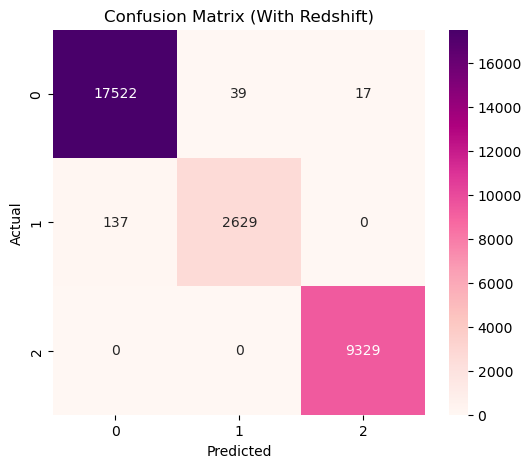

In [14]:
plot_conf_matrix(y_test, y_pred, "Confusion Matrix (With Redshift)")

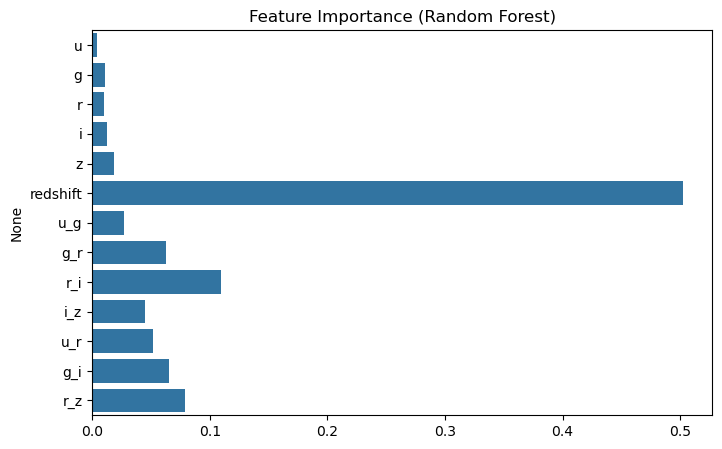

In [15]:
importances = rf.feature_importances_

# feature names 
feature_names = df.drop('class', axis=1).columns

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance (Random Forest)")
plt.show()

                                                              Without Redshift

In [16]:

if 'redshift' in X.columns:
    X = X.drop('redshift', axis=1)

In [17]:
# Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [18]:
#  Random Forest Model 
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_split=5,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,12
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
#  Predictions 
y_pred = rf.predict(X_test)


In [20]:
#  Evaluation 
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9287567822599669

Confusion Matrix:
[[17188    90   300]
 [  161  2250   355]
 [  933   275  8121]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96     17578
           1       0.86      0.81      0.84      2766
           2       0.93      0.87      0.90      9329

    accuracy                           0.93     29673
   macro avg       0.91      0.89      0.90     29673
weighted avg       0.93      0.93      0.93     29673



In [21]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

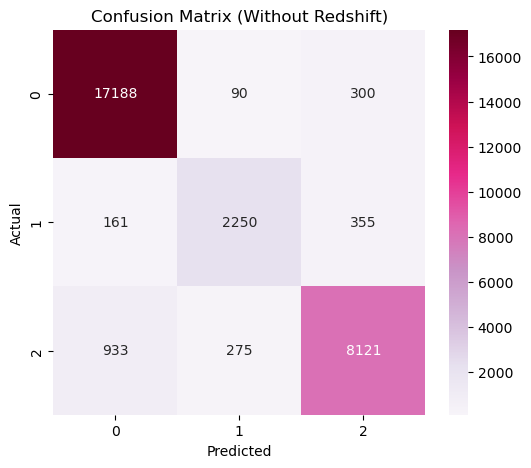

In [22]:
plot_conf_matrix(y_test, y_pred, "Confusion Matrix (Without Redshift)")

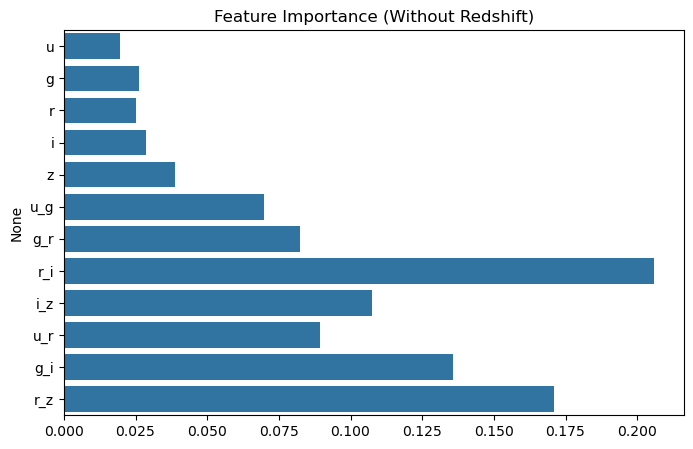

In [23]:
importances_no_z = rf.feature_importances_

feature_names_no_z = np.delete(feature_names, 5)  # remove redshift index

plt.figure(figsize=(8,5))
sns.barplot(x=importances_no_z, y=feature_names_no_z)
plt.title("Feature Importance (Without Redshift)")
plt.show()

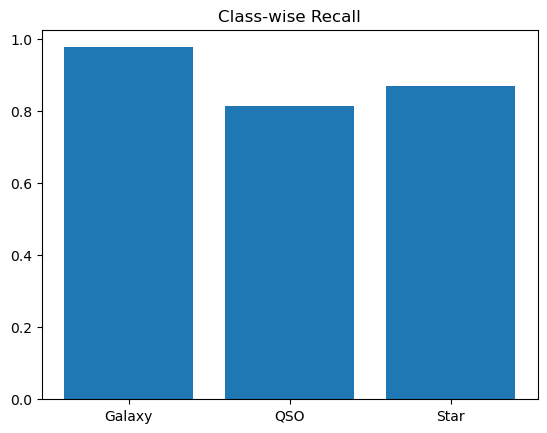

In [25]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, output_dict=True)

recalls = [report[str(i)]['recall'] for i in range(3)]

plt.bar(['Galaxy','QSO','Star'], recalls)
plt.title("Class-wise Recall")
plt.show()